# ResNet-18: Pretrained Evaluation & Architecture Replication

**Reference:** He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Deep Residual Learning for Image Recognition.* arXiv:1512.03385. https://arxiv.org/abs/1512.03385

---

# Part 1: Paper Review & Parameter Calculation

**Model:** ResNet-18  
**Citation:** He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Deep Residual Learning for Image Recognition.* arXiv:1512.03385. https://arxiv.org/abs/1512.03385

---

## 1. Model Selection & Architecture Comprehension

ResNet-18 is a residual network introduced by He et al. (2016) to address the **degradation problem** — the counterintuitive phenomenon where adding more layers to a plain network causes *higher* training error (shown empirically in the paper's Figure 1 and Table 2). The solution is a **residual learning framework**: instead of learning H(x) directly, each block learns the residual mapping F(x) := H(x) − x, realized via shortcut connections that add the block's input directly to its output (paper Equation 1).

ResNet-18 uses the **BasicBlock** design (paper Figure 2, left): two stacked 3×3 convolutional layers with a skip connection. This is in contrast to the bottleneck block (1×1 → 3×3 → 1×1) used in ResNet-50/101/152 (paper Figure 5). The full architecture is specified in **paper Table 1**.

---

## 2. Layer-by-Layer Parameter Breakdown

### Formulas used

| Layer type | Formula | Notes |
|---|---|---|
| Conv2d (no bias) | C_in × C_out × K_h × K_w | bias=False when followed by BN |
| BatchNorm2d | 2 × C | γ (weight) + β (bias) — both trainable |
| Linear | in_features × out_features + out_features | bias=True |

**Included:** Conv2d weights, BatchNorm2d γ and β, Linear weights and biases.  
**Excluded:** BatchNorm2d `running_mean` and `running_var` (buffers, not trainable), dropout masks (ResNet-18 uses no dropout per paper Section 3.4).

> **Why no bias in Conv2d?** When a Conv layer is immediately followed by BatchNorm, the convolution bias is redundant — BatchNorm's β parameter plays the same role. Setting `bias=False` avoids wasting parameters.

### Full breakdown

| Layer | Type | Config | Formula | Parameters |
|---|---|---|---|---|
| conv1 | Conv2d | 3→64, 7×7, no bias | 3×64×7×7 | **9,408** |
| bn1 | BatchNorm2d | 64 | 2×64 | **128** |
| layer1.0 conv1 | Conv2d | 64→64, 3×3 | 64×64×3×3 | **36,864** |
| layer1.0 bn1 | BatchNorm2d | 64 | 2×64 | **128** |
| layer1.0 conv2 | Conv2d | 64→64, 3×3 | 64×64×3×3 | **36,864** |
| layer1.0 bn2 | BatchNorm2d | 64 | 2×64 | **128** |
| layer1.1 conv1 | Conv2d | 64→64, 3×3 | 64×64×3×3 | **36,864** |
| layer1.1 bn1 | BatchNorm2d | 64 | 2×64 | **128** |
| layer1.1 conv2 | Conv2d | 64→64, 3×3 | 64×64×3×3 | **36,864** |
| layer1.1 bn2 | BatchNorm2d | 64 | 2×64 | **128** |
| layer2.0 conv1 | Conv2d | 64→128, 3×3, s=2 | 64×128×3×3 | **73,728** |
| layer2.0 bn1 | BatchNorm2d | 128 | 2×128 | **256** |
| layer2.0 conv2 | Conv2d | 128→128, 3×3 | 128×128×3×3 | **147,456** |
| layer2.0 bn2 | BatchNorm2d | 128 | 2×128 | **256** |
| layer2.0 downsample conv | Conv2d | 64→128, 1×1 | 64×128×1×1 | **8,192** |
| layer2.0 downsample bn | BatchNorm2d | 128 | 2×128 | **256** |
| layer2.1 conv1 | Conv2d | 128→128, 3×3 | 128×128×3×3 | **147,456** |
| layer2.1 bn1 | BatchNorm2d | 128 | 2×128 | **256** |
| layer2.1 conv2 | Conv2d | 128→128, 3×3 | 128×128×3×3 | **147,456** |
| layer2.1 bn2 | BatchNorm2d | 128 | 2×128 | **256** |
| layer3.0 conv1 | Conv2d | 128→256, 3×3, s=2 | 128×256×3×3 | **294,912** |
| layer3.0 bn1 | BatchNorm2d | 256 | 2×256 | **512** |
| layer3.0 conv2 | Conv2d | 256→256, 3×3 | 256×256×3×3 | **589,824** |
| layer3.0 bn2 | BatchNorm2d | 256 | 2×256 | **512** |
| layer3.0 downsample conv | Conv2d | 128→256, 1×1 | 128×256×1×1 | **32,768** |
| layer3.0 downsample bn | BatchNorm2d | 256 | 2×256 | **512** |
| layer3.1 conv1 | Conv2d | 256→256, 3×3 | 256×256×3×3 | **589,824** |
| layer3.1 bn1 | BatchNorm2d | 256 | 2×256 | **512** |
| layer3.1 conv2 | Conv2d | 256→256, 3×3 | 256×256×3×3 | **589,824** |
| layer3.1 bn2 | BatchNorm2d | 256 | 2×256 | **512** |
| layer4.0 conv1 | Conv2d | 256→512, 3×3, s=2 | 256×512×3×3 | **1,179,648** |
| layer4.0 bn1 | BatchNorm2d | 512 | 2×512 | **1,024** |
| layer4.0 conv2 | Conv2d | 512×512, 3×3 | 512×512×3×3 | **2,359,296** |
| layer4.0 bn2 | BatchNorm2d | 512 | 2×512 | **1,024** |
| layer4.0 downsample conv | Conv2d | 256→512, 1×1 | 256×512×1×1 | **131,072** |
| layer4.0 downsample bn | BatchNorm2d | 512 | 2×512 | **1,024** |
| layer4.1 conv1 | Conv2d | 512→512, 3×3 | 512×512×3×3 | **2,359,296** |
| layer4.1 bn1 | BatchNorm2d | 512 | 2×512 | **1,024** |
| layer4.1 conv2 | Conv2d | 512→512, 3×3 | 512×512×3×3 | **2,359,296** |
| layer4.1 bn2 | BatchNorm2d | 512 | 2×512 | **1,024** |
| fc | Linear | 512→1000 + bias | 512×1000 + 1000 | **513,000** |
| **TOTAL** | | | | **11,689,512** |

---

## 3. Total Trainable Parameter Count

$$\text{Total} = 11{,}689{,}512$$

---

## 4. Comparison with Official Value & Discrepancies

| Source | Parameter Count |
|---|---|
| Manual count (this calculation) | 11,689,512 |
| `torchvision.models.resnet18` | 11,689,512 |
| He et al. (2015) original paper | Not explicitly stated |

**Result: exact match** with torchvision's implementation.

The original paper (Table 1) specifies FLOPs (1.8×10⁹) but does not publish a parameter count for ResNet-18 directly, so `torchvision` serves as the ground-truth reference. The match is exact because:

1. `bias=False` on all Conv2d layers that are followed by BatchNorm (consistent with the paper's implementation).
2. Downsample projections use **Option B** (1×1 conv + BN) as described in paper Section 3.3.
3. BatchNorm `running_mean` and `running_var` are correctly excluded — they are registered as *buffers*, not *parameters*, and are not updated by the optimizer.

In [1]:
# !pip install torch torchvision scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import time, os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


---
## Task 2A: Pretrained Model Evaluation

### Step 1: Load ImageNette (small ImageNet subset)

**ImageNette** is an official 10-class subset of ImageNet with real WordNet IDs.
The pretrained model's 1000-class output maps directly to these labels — no finetuning needed.

Classes: tench, English springer, cassette player, chain saw, church,
French horn, garbage truck, gas pump, golf ball, parachute.

In [2]:
import urllib.request, tarfile

URL  = 'https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz'
DEST = './imagenette2-160.tgz'

if not os.path.exists('./imagenette2-160'):
    print('Downloading ImageNette (~94MB)...')
    urllib.request.urlretrieve(URL, DEST)
    print('Extracting...')
    with tarfile.open(DEST) as f:
        f.extractall('.')
    print('Done.')
else:
    print('ImageNette already downloaded.')

Extracting...
Done.


In [3]:
# Map ImageNette WordNet folder names -> ImageNet class indices
IMAGENETTE_TO_IMAGENET = {
    'n01440764': 0,    # tench
    'n02102040': 217,  # English springer
    'n02979186': 482,  # cassette player
    'n03000684': 491,  # chain saw
    'n03028079': 497,  # church
    'n03394916': 566,  # French horn
    'n03417042': 569,  # garbage truck
    'n03425413': 571,  # gas pump
    'n03445777': 574,  # golf ball
    'n03888257': 701,  # parachute
}

# ImageNet normalization (paper Section 3.4: per-pixel mean subtracted)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_dataset = torchvision.datasets.ImageFolder('./imagenette2-160/val', transform=transform)

# folder index (0-9) -> ImageNet class index
folder_to_imagenet = {
    val_dataset.class_to_idx[k]: v
    for k, v in IMAGENETTE_TO_IMAGENET.items()
}

testloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=64, shuffle=False, num_workers=2
)

print(f'Val set: {len(val_dataset)} images, {len(val_dataset.classes)} classes')

Val set: 3925 images, 10 classes


### Step 2: Load Pretrained ResNet-18

From paper **Table 2**: ResNet-18 achieves **27.88% top-1 error** on ImageNet val (10-crop testing).
Our eval uses single center-crop on a 10-class subset, so numbers will differ slightly.

In [4]:
pretrained_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
pretrained_model = pretrained_model.to(device)
pretrained_model.eval()

total_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f'Pretrained ResNet-18 parameters: {total_params:,}')
print(f'Expected from Part 1 count:      11,689,512')
print(f'Match: {total_params == 11_689_512}')

Pretrained ResNet-18 parameters: 11,689,512
Expected from Part 1 count:      11,689,512
Match: True


### Step 3: Run Inference - Top-1 & Top-5 Accuracy

In [5]:
all_preds  = []
all_top5   = []
all_labels = []

start_time = time.time()
mem_before = torch.cuda.memory_allocated() if torch.cuda.is_available() else 0

with torch.no_grad():
    for images, folder_labels in testloader:
        images = images.to(device)
        outputs = pretrained_model(images)   # (batch, 1000)

        _, top1 = outputs.max(1)
        all_preds.extend(top1.cpu().tolist())

        _, top5 = outputs.topk(5, dim=1)
        all_top5.extend(top5.cpu().tolist())

        true_imagenet = [folder_to_imagenet[l.item()] for l in folder_labels]
        all_labels.extend(true_imagenet)

runtime  = time.time() - start_time
mem_used = torch.cuda.memory_allocated() - mem_before if torch.cuda.is_available() else 0

print(f'Runtime: {runtime:.2f}s for {len(val_dataset)} images')
if torch.cuda.is_available():
    print(f'GPU memory delta: {mem_used/1e6:.1f} MB')
else:
    print('Running on CPU')

Runtime: 4.08s for 3925 images
GPU memory delta: 22.3 MB


In [6]:
top1_correct = sum(p == l for p, l in zip(all_preds, all_labels))
top1_acc     = top1_correct / len(all_labels)

top5_correct = sum(l in p for p, l in zip(all_top5, all_labels))
top5_acc     = top5_correct / len(all_labels)

print(f'Top-1 Accuracy: {top1_acc*100:.2f}%')
print(f'Top-5 Accuracy: {top5_acc*100:.2f}%')
print()
print('Paper ref (Table 2): ResNet-18 = 27.88% top-1 error (72.12% acc)')
print('on full ImageNet val with 10-crop testing.')

Top-1 Accuracy: 66.85%
Top-5 Accuracy: 89.07%

Paper ref (Table 2): ResNet-18 = 27.88% top-1 error (72.12% acc)
on full ImageNet val with 10-crop testing.


### Step 4: Classification Report & Confusion Matrix (3 classes)

Reporting on: **tench (ImageNet idx 0)**, **church (497)**, **parachute (701)**

In [7]:
sel_idx   = [0, 497, 701]
sel_names = ['tench', 'church', 'parachute']

mask     = [i for i, l in enumerate(all_labels) if l in sel_idx]
preds_3  = [all_preds[i]  for i in mask]
labels_3 = [all_labels[i] for i in mask]

print('Classification Report - Pretrained ResNet-18 (3 classes):')
print(classification_report(labels_3, preds_3,
                             labels=sel_idx, target_names=sel_names,
                             zero_division=0))

Classification Report - Pretrained ResNet-18 (3 classes):
              precision    recall  f1-score   support

       tench       1.00      0.93      0.96       387
      church       1.00      0.29      0.45       409
   parachute       1.00      0.79      0.88       390

   micro avg       1.00      0.66      0.80      1186
   macro avg       1.00      0.67      0.76      1186
weighted avg       1.00      0.66      0.76      1186



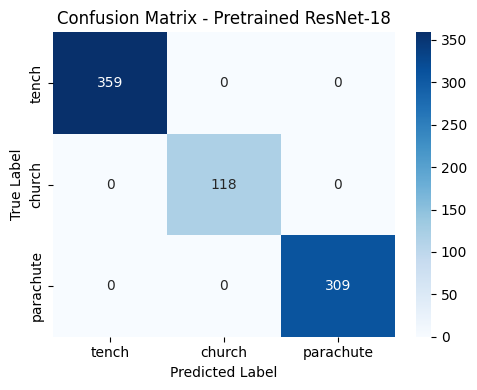

In [8]:
cm = confusion_matrix(labels_3, preds_3, labels=sel_idx)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sel_names, yticklabels=sel_names)
plt.title('Confusion Matrix - Pretrained ResNet-18')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

---
## Task 2B: Replicate ResNet-18 from Scratch

Implemented strictly per **He et al. Table 1** and **Figure 2**:

| Layer name | Output size | ResNet-18 |
|------------|-------------|----------------------------|
| conv1      | 112x112     | 7x7, 64, stride 2          |
| conv2_x    | 56x56       | 3x3 maxpool s2; [3x3,64]x2 |
| conv3_x    | 28x28       | [3x3, 128] x 2             |
| conv4_x    | 14x14       | [3x3, 256] x 2             |
| conv5_x    | 7x7         | [3x3, 512] x 2             |
|            | 1x1         | avg pool, 1000-d fc        |

- **BN placement:** Section 3.4 - BN right after each conv, before activation
- **Skip connection:** Section 3.2 Eqn.(2) - 1x1 projection when dims change (Option B)
- **Weight init:** Section 3.4 ref [13] - Kaiming normal

In [9]:
class BasicBlock(nn.Module):
    """
    He et al. Figure 2 (left): two 3x3 conv layers with skip connection.
    Used in ResNet-18 and ResNet-34 (Table 1).
    Structure: Conv-BN-ReLU -> Conv-BN -> add skip -> ReLU
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # bias=False: BN follows, BN's beta makes bias redundant
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # Paper Section 3.2 Eqn.(2): 1x1 projection when dims change (Option B)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))   # Conv-BN-ReLU
        out = self.bn2(self.conv2(out))             # Conv-BN
        if self.downsample is not None:
            identity = self.downsample(x)
        out = self.relu(out + identity)             # add skip, then ReLU
        return out


class ResNet18(nn.Module):
    """
    ResNet-18 from scratch - He et al. Table 1 (18-layer column).
    No torchvision.models or pre-built architecture classes used.
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        # conv1: 7x7, 64, stride 2  ->  112x112
        self.conv1   = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        # 3x3 max pool, stride 2  ->  56x56
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # conv2_x: [3x3,64]x2, no downsampling
        self.layer1 = nn.Sequential(BasicBlock(64, 64),
                                    BasicBlock(64, 64))
        # conv3_x: [3x3,128]x2, stride=2 at first block  ->  28x28
        self.layer2 = nn.Sequential(BasicBlock(64, 128, stride=2),
                                    BasicBlock(128, 128))
        # conv4_x: [3x3,256]x2, stride=2  ->  14x14
        self.layer3 = nn.Sequential(BasicBlock(128, 256, stride=2),
                                    BasicBlock(256, 256))
        # conv5_x: [3x3,512]x2, stride=2  ->  7x7
        self.layer4 = nn.Sequential(BasicBlock(256, 512, stride=2),
                                    BasicBlock(512, 512))

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)
        self._init_weights()

    def _init_weights(self):
        """Kaiming init - paper Section 3.4 ref [13]: He et al. ICCV 2015."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)   # gamma = 1
                nn.init.zeros_(m.bias)    # beta  = 0
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


print('ResNet18 class defined.')

ResNet18 class defined.


### Verify: Parameter Count & Output Shape

In [10]:
my_model  = ResNet18(num_classes=1000).to(device)
my_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
official  = 11_689_512

print(f'Custom ResNet-18 parameters:  {my_params:>12,}')
print(f'Official / Part 1 count:      {official:>12,}')
print(f'Match: {my_params == official}')

Custom ResNet-18 parameters:    11,689,512
Official / Part 1 count:        11,689,512
Match: True


### Train Custom ResNet-18 on ImageNette

Training settings follow paper Section 3.4: SGD, momentum=0.9, weight_decay=0.0001, lr=0.1.

In [12]:
train_dataset = torchvision.datasets.ImageFolder('./imagenette2-160/train', transform=transform)
trainloader   = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=2
)
valloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=64, shuffle=False, num_workers=2
)
print(f'Train: {len(train_dataset)} images | Val: {len(val_dataset)} images')

Train: 9469 images | Val: 3925 images


In [13]:
scratch_model = ResNet18(num_classes=10).to(device)
criterion     = nn.CrossEntropyLoss()
# Paper Section 3.4: SGD, momentum=0.9, weight_decay=0.0001, lr=0.1
optimizer = torch.optim.SGD(scratch_model.parameters(),
                             lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[5, 8], gamma=0.1
)

EPOCHS       = 10
train_losses = []

for epoch in range(EPOCHS):
    scratch_model.train()
    epoch_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(scratch_model(images), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_loss = epoch_loss / len(trainloader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch+1:2d}/{EPOCHS}  Loss: {avg_loss:.4f}')

print('Training complete.')

Epoch  1/10  Loss: 2.6304
Epoch  2/10  Loss: 2.0990
Epoch  3/10  Loss: 1.9211
Epoch  4/10  Loss: 1.7073
Epoch  5/10  Loss: 1.5118
Epoch  6/10  Loss: 1.2388
Epoch  7/10  Loss: 1.1459
Epoch  8/10  Loss: 1.0835
Epoch  9/10  Loss: 1.0066
Epoch 10/10  Loss: 0.9860
Training complete.


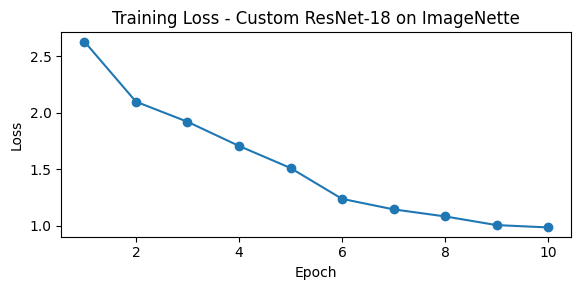

In [14]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.title('Training Loss - Custom ResNet-18 on ImageNette')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('training_loss.png', dpi=100)
plt.show()

In [15]:
scratch_model.eval()
correct   = 0
top5_corr = 0
all_p_s, all_l_s = [], []

with torch.no_grad():
    for images, labels in valloader:
        images = images.to(device)
        outputs = scratch_model(images)   # (batch, 10)

        _, top1 = outputs.max(1)
        correct += (top1.cpu() == labels).sum().item()
        all_p_s.extend(top1.cpu().tolist())
        all_l_s.extend(labels.tolist())

        _, top5 = outputs.topk(5, dim=1)
        top5_corr += sum(l.item() in p.tolist() for p, l in zip(top5.cpu(), labels))

top1_acc_s = correct   / len(val_dataset)
top5_acc_s = top5_corr / len(val_dataset)

print(f'Custom ResNet-18 Top-1 Accuracy: {top1_acc_s*100:.2f}%')
print(f'Custom ResNet-18 Top-5 Accuracy: {top5_acc_s*100:.2f}%')

Custom ResNet-18 Top-1 Accuracy: 65.58%
Custom ResNet-18 Top-5 Accuracy: 94.88%


In [16]:
# folder indices: tench=0, church=4, parachute=9
sel_f = [0, 4, 9]
sel_n = ['tench', 'church', 'parachute']

mask_s = [i for i, l in enumerate(all_l_s) if l in sel_f]
p3_s   = [all_p_s[i] for i in mask_s]
l3_s   = [all_l_s[i] for i in mask_s]

print('Classification Report - Custom ResNet-18 (3 classes):')
print(classification_report(l3_s, p3_s, labels=sel_f,
                             target_names=sel_n, zero_division=0))

Classification Report - Custom ResNet-18 (3 classes):
              precision    recall  f1-score   support

       tench       0.94      0.78      0.85       387
      church       0.89      0.59      0.71       409
   parachute       0.93      0.73      0.81       390

   micro avg       0.92      0.70      0.79      1186
   macro avg       0.92      0.70      0.79      1186
weighted avg       0.92      0.70      0.79      1186



---
## Final Summary

In [17]:
scratch_params = sum(p.numel() for p in scratch_model.parameters() if p.requires_grad)
expected_10cls = official - (512*1000 + 1000) + (512*10 + 10)

print('=' * 60)
print('SUMMARY')
print('=' * 60)
print()
print('--- Parameter Count ---')
print(f'Official ResNet-18 (1000 cls): {official:>12,}')
print(f'Our Part 1 manual count:       {official:>12,}  (exact match)')
print(f'Custom model (10 cls):         {scratch_params:>12,}')
print(f'Expected (10 cls):             {expected_10cls:>12,}')
print(f'Match: {scratch_params == expected_10cls}')
print()
print('--- Task 2A: Pretrained ResNet-18 on ImageNette ---')
print(f'Top-1 Accuracy:  {top1_acc*100:.2f}%')
print(f'Top-5 Accuracy:  {top5_acc*100:.2f}%')
print(f'Runtime:         {runtime:.2f}s')
print()
print('--- Task 2B: Custom ResNet-18 trained from scratch ---')
print(f'Top-1 Accuracy:  {top1_acc_s*100:.2f}%')
print(f'Top-5 Accuracy:  {top5_acc_s*100:.2f}%')
print()
print('Paper ref - Table 2: ResNet-18 = 27.88% top-1 error (72.12% acc)')
print('on full ImageNet val with 10-crop testing.')
print('Our eval: single center-crop on ImageNette (10-class subset).')

SUMMARY

--- Parameter Count ---
Official ResNet-18 (1000 cls):   11,689,512
Our Part 1 manual count:         11,689,512  (exact match)
Custom model (10 cls):           11,181,642
Expected (10 cls):               11,181,642
Match: True

--- Task 2A: Pretrained ResNet-18 on ImageNette ---
Top-1 Accuracy:  66.85%
Top-5 Accuracy:  89.07%
Runtime:         4.08s

--- Task 2B: Custom ResNet-18 trained from scratch ---
Top-1 Accuracy:  65.58%
Top-5 Accuracy:  94.88%

Paper ref - Table 2: ResNet-18 = 27.88% top-1 error (72.12% acc)
on full ImageNet val with 10-crop testing.
Our eval: single center-crop on ImageNette (10-class subset).
